<a href="https://colab.research.google.com/github/V1LL4pro/Deep-Learning/blob/Corte-1/T3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install keras-tuner
!pip install bitarray

import numpy as np
import os
import gc
from PIL import Image
from tqdm import tqdm
import shutil
import requests
import urllib.parse
import tensorflow as tf
from tensorflow import keras
from keras import layers, backend as K
from sklearn.model_selection import train_test_split
from keras_tuner import RandomSearch
import matplotlib.pyplot as plt

# 1. Descarga Dataset

> Google quickdraw dataset



In [2]:
# Configuración inicial
BASE_PATH = "/content/quickdraw_dataset"
MAX_IMAGES_PER_CLASS = 2222
continuar_proceso = True  # Descarga por defecto

# Verificar existencia del directorio
if os.path.exists(BASE_PATH):
    respuesta = input(f"⚠️ El directorio {BASE_PATH} ya existe. ¿Borrar y recrear? [y/N]: ")
    if respuesta.lower() == 'y':
        print(f"🗑️ Eliminando {BASE_PATH}...")
        shutil.rmtree(BASE_PATH)
    else:
        print("🚨 Proceso cancelado. Usando directorio existente.")
        continuar_proceso = False  # Desactivar la descarga

# Descarga
if continuar_proceso:
    print("\n🚀 Iniciando proceso de descarga...")

    # Obtener categorías
    categories_url = "https://raw.githubusercontent.com/googlecreativelab/quickdraw-dataset/master/categories.txt"
    response = requests.get(categories_url)
    original_categories = [line.strip() for line in response.text.split('\n') if line.strip()]

    # Crear estructura de directorios
    os.makedirs(BASE_PATH, exist_ok=True)
    for category in original_categories:
        safe_name = category.replace(" ", "_")
        os.makedirs(os.path.join(BASE_PATH, safe_name), exist_ok=True)

    def process_category(original_name):
        try:
            url_name = urllib.parse.quote(original_name)
            dir_name = original_name.replace(" ", "_")

            url = f"https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/{url_name}.npy"
            response = requests.get(url, stream=True)
            response.raise_for_status()

            temp_path = os.path.join(BASE_PATH, f"{dir_name}.npy")
            with open(temp_path, "wb") as f:
                f.write(response.content)

            images = np.load(temp_path)
            np.random.shuffle(images)

            for i, img_data in enumerate(images[:MAX_IMAGES_PER_CLASS]):
                img = Image.fromarray(img_data.reshape(28, 28).astype(np.uint8))
                img.save(os.path.join(BASE_PATH, dir_name, f"{dir_name}_{i}.png"))

            os.remove(temp_path)

        except Exception as e:
            print(f"❌ Error en {original_name}: {str(e)}")

    # Procesar categorías
    for category in tqdm(original_categories, desc="Procesando"):
        process_category(category)

    print("\n🎉 ¡Proceso completado con éxito!")

⚠️ El directorio /content/quickdraw_dataset ya existe. ¿Borrar y recrear? [y/N]: n
🚨 Proceso cancelado. Usando directorio existente.



# 2. Carga y preparación de datos


> train - 80%, val - 10%, test - 10%

In [3]:
def load_dataset(base_path, num_classes=345, max_per_class=MAX_IMAGES_PER_CLASS):
    images = []
    labels = []
    class_names = sorted(os.listdir(base_path))

    for label_idx, class_name in enumerate(class_names[:num_classes]):
        class_path = os.path.join(base_path, class_name)
        print(f"Cargando clase #{label_idx+1} {class_name}...")

        for i, img_file in enumerate(os.listdir(class_path)[:max_per_class]):
            img_path = os.path.join(class_path, img_file)
            img = keras.preprocessing.image.load_img(
                img_path, color_mode='grayscale', target_size=(28, 28))
            img_array = keras.preprocessing.image.img_to_array(img)
            images.append(img_array / 255.0) # Normalización
            labels.append(label_idx)

    return np.array(images), np.array(labels)

# Cargar datos
X, y = load_dataset('/content/quickdraw_dataset', num_classes=345, max_per_class=MAX_IMAGES_PER_CLASS)

# Dividir datos
# Primera división: 80% entrenamiento, 20% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.2,          # 20% para validación + test
    random_state=666        # Semilla aleatoria demoniaca
)

del X, y  # Liberar memoria

# Segunda división: 10% validación, 10% test (del 20% temporal)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,          # Mitad del 20% (10% total)
    random_state=666        # Semilla aleatoria demoniaca
)

del X_temp, y_temp  # Liberar memoria

Cargando clase #1 The_Eiffel_Tower...
Cargando clase #2 The_Great_Wall_of_China...
Cargando clase #3 The_Mona_Lisa...
Cargando clase #4 aircraft_carrier...
Cargando clase #5 airplane...
Cargando clase #6 alarm_clock...
Cargando clase #7 ambulance...
Cargando clase #8 angel...
Cargando clase #9 animal_migration...
Cargando clase #10 ant...
Cargando clase #11 anvil...
Cargando clase #12 apple...
Cargando clase #13 arm...
Cargando clase #14 asparagus...
Cargando clase #15 axe...
Cargando clase #16 backpack...
Cargando clase #17 banana...
Cargando clase #18 bandage...
Cargando clase #19 barn...
Cargando clase #20 baseball...
Cargando clase #21 baseball_bat...
Cargando clase #22 basket...
Cargando clase #23 basketball...
Cargando clase #24 bat...
Cargando clase #25 bathtub...
Cargando clase #26 beach...
Cargando clase #27 bear...
Cargando clase #28 beard...
Cargando clase #29 bed...
Cargando clase #30 bee...
Cargando clase #31 belt...
Cargando clase #32 bench...
Cargando clase #33 bicycle..

# 3. Construcción del modelo base


> Capas ocultas: 2 - 4

> Neuronas: 512 - 2048, pasos de 512

> LR: 0.05, 0.01, 0.001, 0.0005



In [4]:
def build_model(hp=None):
    model = keras.Sequential()

    model.add(keras.Input(shape=(28, 28, 1)))  # Forma de entrada
    model.add(layers.Flatten())

    if hp:
        num_layers = hp.Int('num_layers', 2, 4)  # Entre 2 y 4 capas
        learning_rate = hp.Choice('learning_rate', [5e-2, 1e-2, 1e-3, 5e-4])

        # Definir unidades independientes para cada posible capa
        units = []
        for i in range(num_layers):
            units.append(
                hp.Int(f'units_{i}',
                       min_value=512,
                       max_value=2048,
                       step=512)
            )

        # Añadir solo el número de capas seleccionado
        for i in range(num_layers):
            model.add(layers.Dense(units[i], activation='relu'))

    else:
        # Configuración por defecto (3 capas con diferentes unidades)
        num_layers = 3
        units = [2048, 1024, 512]  # Unidades decrecientes
        learning_rate = 1e-2

        for u in units:
            model.add(layers.Dense(u, activation='relu'))

    model.add(layers.Dense(345, activation='softmax'))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# 4. Búsqueda de hiperparámetros

> 50 intentos para encontrar los mejores hiperparametros para val_accuracy

> EarlyStop con tolerancia de 3 epocas para evitar overfitting

> Epocas: 20

> Lote: 256







In [5]:
class MemoryCleaner(keras.callbacks.Callback):
    def on_train_end(self, logs=None):
        K.clear_session()
        gc.collect()

tuner = RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=50,
    executions_per_trial=1,
    directory='tuner_dir',
    project_name='quickdraw_mlp'
)

tuner.search(
    X_train, y_train,
    epochs=20,
    validation_data=(X_val, y_val),
    batch_size=256,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=3),
        MemoryCleaner()
    ]
)

Trial 50 Complete [00h 02m 17s]
val_accuracy: 0.24195462465286255

Best val_accuracy So Far: 0.5195084810256958
Total elapsed time: 02h 00m 59s


# 5. Entrenamiento del mejor modelo

> EarlyStop con tolerancia de 5 epocas para evitar overfitting

> Epocas: 100

> Lote: 2222

In [7]:
best_model = tuner.get_best_models(num_models=1)[0]
history = best_model.fit(
    X_train, y_train,
    epochs=100,
    validation_data=(X_val, y_val),
    batch_size=2222,
    callbacks=[keras.callbacks.EarlyStopping(patience=5)]
)

# Guardar modelo
best_model.save('best_mlp_model.h5')

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Epoch 1/100
276/276 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.7030 - loss: 1.1666 - val_accuracy: 0.5384 - val_loss: 2.0811
Epoch 2/100
276/276 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.7510 - loss: 0.9799 - val_accuracy: 0.5330 - val_loss: 2.1468
Epoch 3/100
276/276 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.7798 - loss: 0.8668 - val_accuracy: 0.5300 - val_loss: 2.2255
Epoch 4/100
276/276 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.8048 - loss: 0.7668 - val_accuracy: 0.5258 - val_loss: 2.3081
Epoch 5/100
276/276 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.8309 - loss: 0.6678 - val_accuracy: 0.5213 - val_loss: 2.4027
Epoch 6/100
276/276 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.8559 - loss: 0.5769 - val_accuracy: 0.5188 - val_loss: 2.5273


# 6. Resultados

2396/2396 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.5209 - loss: 2.5095

Exactitud con test-10%: 0.5213


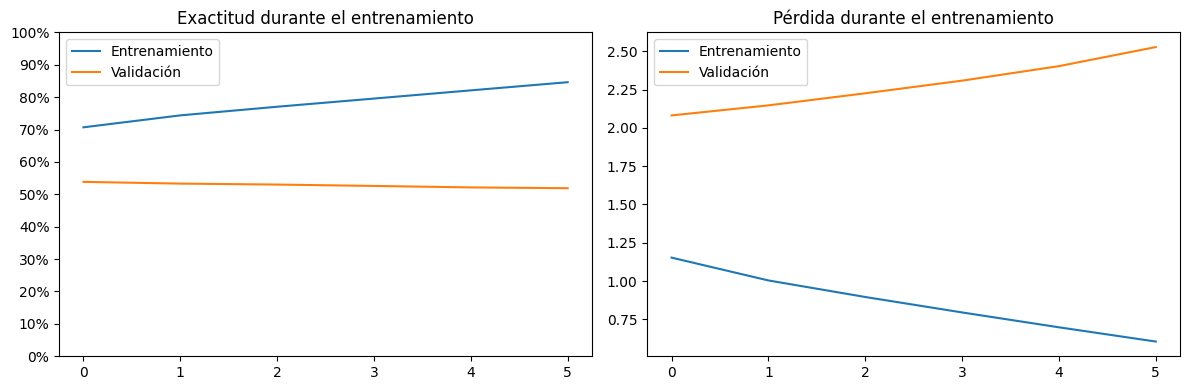

In [8]:
# Prediccion con test
test_loss, test_acc = best_model.evaluate(X_test, y_test)
print(f"\nExactitud con test-10%: {test_acc:.4f}")

# Grafica
plt.figure(figsize=(12, 4))

# Gráfico de exactitud
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Exactitud durante el entrenamiento')
plt.ylim(0, 1)  # Establecer rango 0-100%
plt.yticks(np.arange(0, 1.1, 0.1))  # Marcas cada 10%
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y*100)}%'))  # Formato porcentual
plt.legend()

# Gráfico de pérdida
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida durante el entrenamiento')
plt.legend()

plt.tight_layout()
plt.show()